**Author:** Christopher Millward<br>
**Date:** June 19, 2026

The R matrices built from the data were failing my orthonormality tests. The purpose of this notebook is to audit the orthonormality of the dataset.

---

I'm going to perform the following audits:
1. Calculate how far away from orthonormality each R matrix is in each data file. 
2. Visualize the distributions of these variances

In [35]:
# set root folder to project root
import os 
import sys

root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

In [36]:
# Import the data
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy.stats import describe
from utils.data_loading import load_participant_details
from utils.kinematics.general_helpers import create_rotation_matrices
import time
from pprint import pprint

participant_details = load_participant_details('../raw_data/participant_details.xlsx')

In [37]:
pprint(participant_details[0])

{'age': 74,
 'dominant_arm': 'right',
 'filename': '1_R_MATRICES 2016-5-10',
 'left': {'glenohumeral_rotation': None,
          'humerothoracic_rotation': None,
          'total_rotation_x': None,
          'total_rotation_y': None,
          'total_rotation_z': None},
 'right': {'glenohumeral_rotation': None,
           'humerothoracic_rotation': None,
           'total_rotation_x': None,
           'total_rotation_y': None,
           'total_rotation_z': None},
 'rtsa_side': 'right',
 'tsa_side': 'left'}


In [48]:
# Helper functions
def calculate_and_save_variances(data, rtsa_side, fpath):
    """Helper function to calculate and save variances for a single arm"""

    # build matrices
    matrices = create_rotation_matrices(data, rtsa_side)

    # calculate variance from orthonormality
    I = np.eye(3)
    ortho_variance_arrays = (np.transpose(matrices, axes=(0, 2, 1)) @ matrices - I)
    variances = np.linalg.norm(ortho_variance_arrays, axis=(1, 2))

    # save variances
    variance_data.extend(
        {
            "participant": fpath,
            "variance": v,
        }
        for v in variances
    )

def get_rtsa_sides(p_details):
    """
    Helper function to properly format the RTSA sides for a participant 
    (will properly fix this in a separate commit). Returning in a list 
    just in case someone is bilateral.
    """
    match p_details['rtsa_side']:
        case "right":
            return ["R"]
        case "left":
            return ["L"]
        case "both":
            return ["R", "L"]
        case None:
            return None


# Analysis
start_time = time.perf_counter()
variance_data = []
for participant in participant_details:
    # get data
    fpath = participant['filename']
    data = np.loadtxt(
        f'../raw_data/{fpath}', delimiter='\t', skiprows=1, usecols=range(1, 19))

    # Run analysis
    sides = get_rtsa_sides(participant)
    if sides is not None:
        for side in sides:
            calculate_and_save_variances(data, side, fpath)


end_time = time.perf_counter()
print(f"Time taken: {end_time - start_time:.2f} seconds")

Time taken: 44.69 seconds


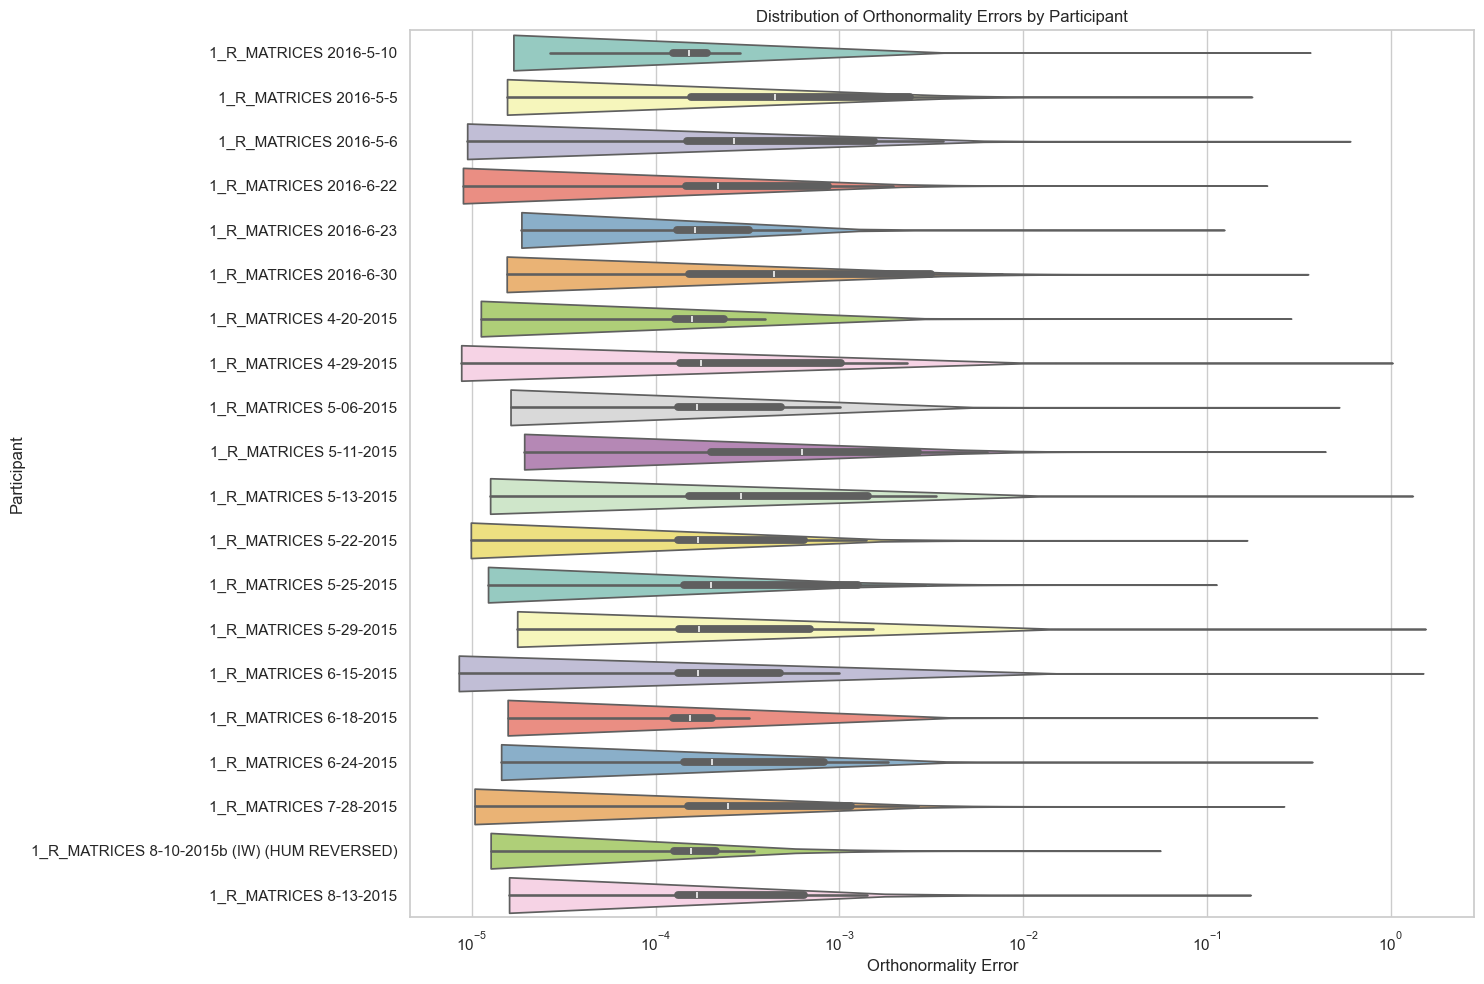

In [ ]:
# Plot distributions
sns.set_theme(style="whitegrid", context="notebook")
plot_data = pd.DataFrame(variance_data)

plt.figure(figsize=(15, 10))

sns.violinplot(
    data=plot_data,
    y="participant",
    x="variance",
    cut=0,
    palette="Set3",
    hue="participant",
    legend=False,
)

plt.xscale("log")

plt.title("Distribution of Orthonormality Errors by Participant")
plt.xlabel("Orthonormality Error")
plt.ylabel("Participant")
plt.tight_layout()
plt.show()

In [60]:
print("=== Participant-Level Variance Descriptions ===")
print(plot_data.groupby("participant")["variance"].describe().to_markdown())

print("\n\n=== Overall Variance Description ===")
all_descr = plot_data.groupby("participant")["variance"].describe()['mean'].describe()
print(all_descr.to_markdown())

=== Participant-Level Variance Descriptions ===
| participant                                 |   count |        mean |        std |         min |         25% |         50% |         75% |       max |
|:--------------------------------------------|--------:|------------:|-----------:|------------:|------------:|------------:|------------:|----------:|
| 1_R_MATRICES 2016-5-10                      |  404800 | 0.000450288 | 0.00242713 | 1.68493e-05 | 0.000124327 | 0.000152516 | 0.000189367 | 0.364534  |
| 1_R_MATRICES 2016-5-5                       |  404913 | 0.00235723  | 0.00492682 | 1.55641e-05 | 0.000156083 | 0.000448457 | 0.00241732  | 0.175938  |
| 1_R_MATRICES 2016-5-6                       |  365000 | 0.00170722  | 0.00522165 | 9.44695e-06 | 0.000149084 | 0.000266199 | 0.00154711  | 0.601645  |
| 1_R_MATRICES 2016-6-22                      |  233732 | 0.00107116  | 0.00289256 | 8.95834e-06 | 0.000146826 | 0.00021973  | 0.00087033  | 0.212051  |
| 1_R_MATRICES 2016-6-23          

The majority of the data is less than 1e-3 off from orthonormal.

We need to decide what a reasonable threshold is and how to handle data that doesn't meet this threshold.